In [3]:
import torch
import os
import random
import utils
import data_utils
import json

import cbm
import plots

In [4]:
# change this to the correct model dir, everything else should be taken care of
load_dir = "saved_models/chestxray_cbm_2025_03_16_13_42"
device = "cuda"

with open(os.path.join(load_dir, "args.txt"), "r") as f:
    args = json.load(f)
dataset = args["dataset"]
_, target_preprocess = data_utils.get_target_model(args["backbone"], device)
model = cbm.load_cbm(load_dir, device)

d:\GitHub\Label-free-CBM\cbm.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  W_c = torch.load(os.path.join(load_dir ,"W_c.pt"), map_location=device)
d:\GitHub\Label-fre

In [5]:
val_d_probe = dataset+"_val"
cls_file = data_utils.LABEL_FILES[dataset]

val_data_t = data_utils.get_data(val_d_probe, preprocess=target_preprocess)
val_pil_data = data_utils.get_data(val_d_probe)

In [6]:
with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

## Measure accuracy

In [7]:
accuracy = utils.get_accuracy_cbm(model, val_data_t, device)
print("Accuracy: {:.2f}%".format(accuracy*100))

100%|██████████| 113/113 [04:18<00:00,  2.29s/it]

Accuracy: 43.33%


## Show final layer weights for some classes

You can build a Sankey diagram of weights by copying the incoming weights printed below into https://sankeymatic.com/build/

In [8]:
to_show = random.choices([i for i in range(len(classes))], k=1)

for i in to_show:
    print("Output class:{} - {}".format(i, classes[i]))
    print("Incoming weights:")
    for j in range(len(concepts)):
        if torch.abs(model.final.weight[i,j])>0.05:
            print("{} [{:.4f}] {}".format(concepts[j], model.final.weight[i,j], classes[i]))

Output class:0 - Atelectasis
Incoming weights:
-abdomen [-0.0617] Atelectasis
-interstitial opacities [0.0508] Atelectasis
-lung abnormality [0.0511] Atelectasis
-lungs [-0.2071] Atelectasis
clear lung fields [-0.0634] Atelectasis
elevation of the diaphragm [-0.0889] Atelectasis
enlarged air spaces [0.1536] Atelectasis
heart [0.1541] Atelectasis
overinflation of air spaces [0.1865] Atelectasis
peribronchial cuffing [0.0527] Atelectasis
respiratory disorder [-0.0541] Atelectasis
restrictive lung disease [-0.0598] Atelectasis


In [9]:
to_show = random.choices([i for i in range(len(classes))], k=2)

top_weights, top_weight_ids = torch.topk(model.final.weight, k=5, dim=1)
bottom_weights, bottom_weight_ids = torch.topk(model.final.weight, k=5, dim=1, largest=False)

for i in to_show:
    print("Class {} - {}".format(i, classes[i]))
    out = "Highest weights: "
    for j in range(top_weights.shape[1]):
        idx = int(top_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], top_weights[i, j])
    print(out)
    out = "Lowest weights: "
    for j in range(bottom_weights.shape[1]):
        idx = int(bottom_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], bottom_weights[i, j])
    print(out + "\n")

Class 13 - Hernia
Highest weights: surgery:0.026, intestines:0.014, fluid or pus:0.010, rib cage:0.002, -abdomen:0.000, 
Lowest weights: -tumor:-0.101, cardiovascular condition:-0.049, -CT scan:-0.005, -abdominal condition:0.000, -abdomen:0.000, 

Class 0 - Atelectasis
Highest weights: overinflation of air spaces:0.187, heart:0.154, enlarged air spaces:0.154, peribronchial cuffing:0.053, -lung abnormality:0.051, 
Lowest weights: -lungs:-0.207, elevation of the diaphragm:-0.089, clear lung fields:-0.063, -abdomen:-0.062, restrictive lung disease:-0.060, 



In [10]:
# Some features may not have any non-zero outgoing weights, 
# i.e. these are not used by the model and should be deleted for better performance
weight_contribs = torch.sum(torch.abs(model.final.weight), dim=0)
print("Num concepts with outgoing weights:{}/{}".format(torch.sum(weight_contribs>1e-5), len(weight_contribs)))

Num concepts with outgoing weights:64/64


## Explain model reasoning for random inputs

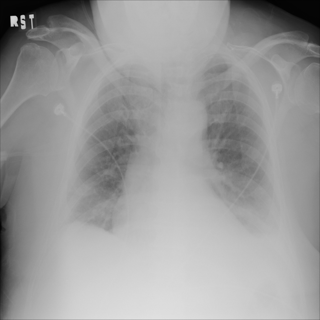

Image:526 Gt:Atelectasis, 1st Pred:Cardiomegaly, 2.593, 2nd Pred:Pneumonia, 1.470


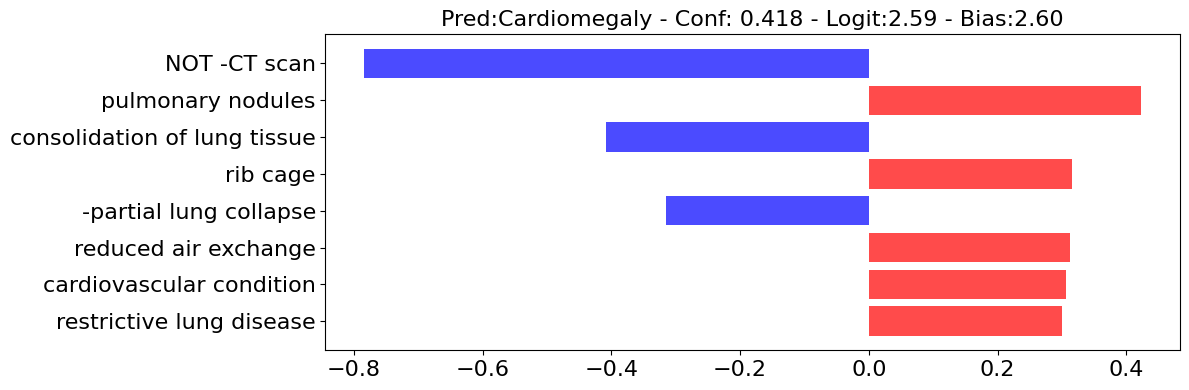

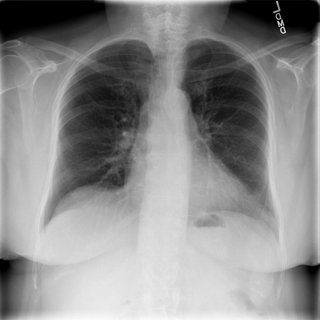

Image:7510 Gt:Fibrosis, 1st Pred:Cardiomegaly, 2.838, 2nd Pred:Pneumonia, 1.395


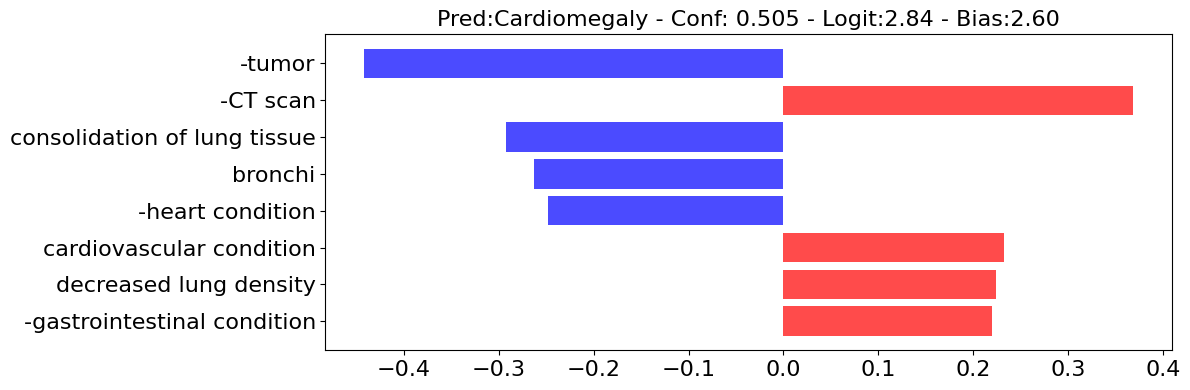

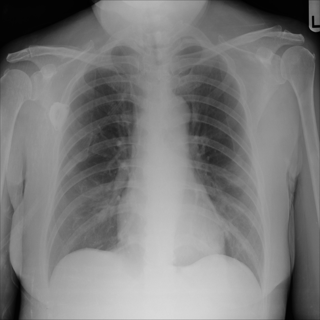

Image:20286 Gt:Cardiomegaly, 1st Pred:Cardiomegaly, 3.044, 2nd Pred:Pneumonia, 1.246


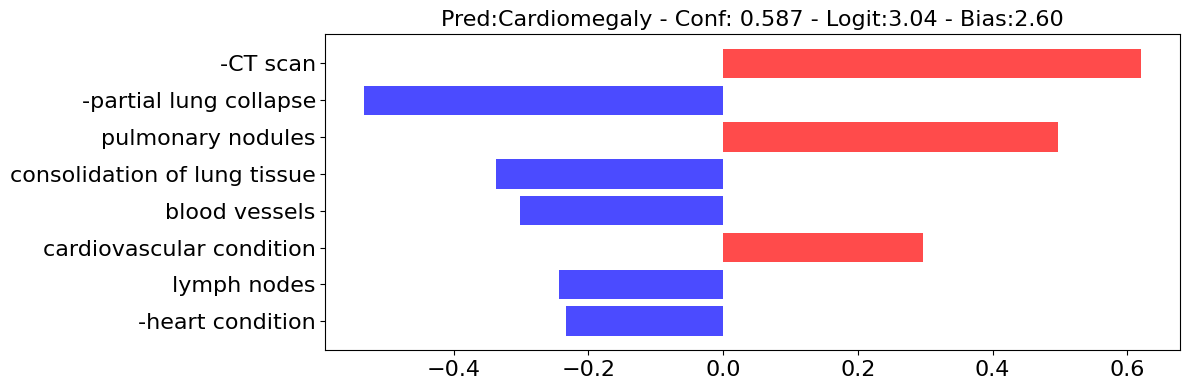

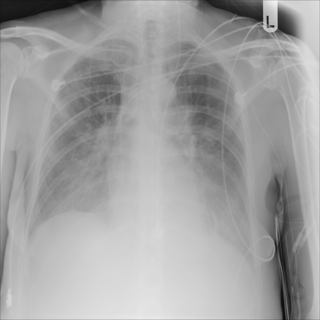

Image:16657 Gt:Cardiomegaly, 1st Pred:Cardiomegaly, 2.309, 2nd Pred:Pneumonia, 1.499


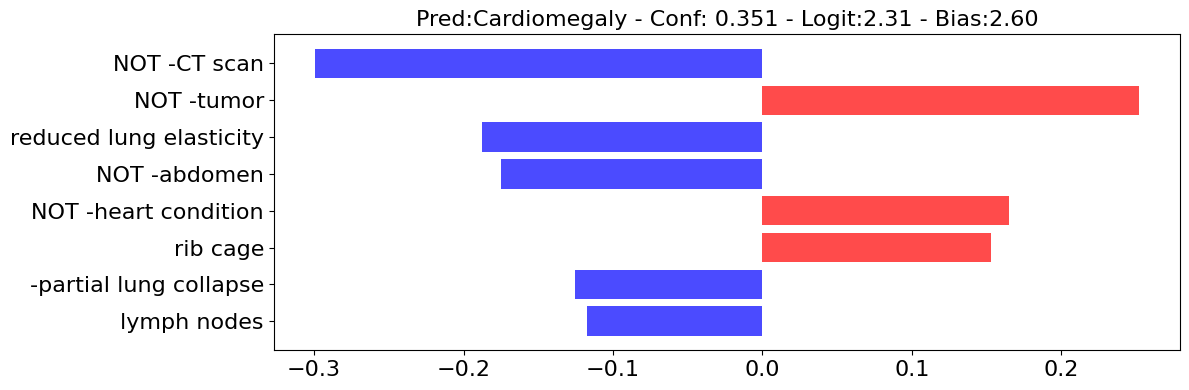

In [11]:
to_display = random.sample([i for i in range(len(val_pil_data))], k=4)

with torch.no_grad():
    for i in to_display:
        image, label = val_pil_data[i]
        x, _ = val_data_t[i]
        x = x.unsqueeze(0).to(device)
        display(image.resize([320,320]))
        
        outputs, concept_act = model(x)
        
        top_logit_vals, top_classes = torch.topk(outputs[0], dim=0, k=2)
        conf = torch.nn.functional.softmax(outputs[0], dim=0)
        print("Image:{} Gt:{}, 1st Pred:{}, {:.3f}, 2nd Pred:{}, {:.3f}".format(i, classes[int(label)], classes[top_classes[0]], top_logit_vals[0],
                                                                      classes[top_classes[1]], top_logit_vals[1]))
        
        for k in range(1):
            contributions = concept_act[0]*model.final.weight[top_classes[k], :]
            feature_names = [("NOT " if concept_act[0][i] < 0 else "") + concepts[i] for i in range(len(concepts))]
            values = contributions.cpu().numpy()
            max_display = min(int(sum(abs(values)>0.005))+1, 8)
            title = "Pred:{} - Conf: {:.3f} - Logit:{:.2f} - Bias:{:.2f}".format(classes[top_classes[k]],
                             conf[top_classes[k]], top_logit_vals[k], model.final.bias[top_classes[k]])
            plots.bar(values, feature_names, max_display=max_display, title=title, fontsize=16)